# Trajectory Inference and Cell-Cell Interactions in ENKTCL (Figure 6)

**Manuscript Context:** his notebook contains the code and workflows used to generate **Figure 6a–f** and associated supplementary analyses for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to reconstruct the developmental trajectories of NK and T cells and to characterize the cell-cell communication networks within the tumor microenvironment before and after PD-1 blockade. Specifically, we:
1.  Utilize **Monocle 3** and **staVIA** to perform pseudotemporal ordering of NK cells. We visualize the UMAP and graph-based representations to identify terminal clusters and distinct NK substates.
2.  Quantify changes in lineage proportions over pseudotime, comparing the dynamic shifts in NK cell lineages across pre-ICI, post-ICI, and PBMC samples.
3.  Employ three-dimensional diffusion map visualization to trace the gene expression trajectories of NK and T cells, annotating key selected genes to understand transcriptional evolution.
4.  Generate bubble heatmaps to illustrate immune checkpoint-associated ligand-receptor interactions between exhausted T cells (e.g., T05: pTex_CD39, T06: Tex_CD8) and malignant NK/T cells. We assess interaction strength and statistical significance (-log₁₀P) to identify significant communication shifts induced by therapy.

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import numpy as np
import scirpy as ir
import matplotlib as mpl
from scipy.sparse import csr_matrix
import matplotlib.ticker as ticker
import os
mpl.rcParams['font.family'] = 'Arial'
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
import sys
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


In [2]:
figPath = "./figures/fig6"
tablePath = "./tables"
irPath = "./data/NKTCL-ir.h5ad"
TPath = './data/NKTCL_T.h5ad'
CD8TPath = './data/NKTCL_CD8T.h5ad'
CD4TPath = './data/NKTCL_CD4T.h5ad'
NKPath = './data/NKTCL_NK.h5ad'
TprolPath = './data/NKTCL_Tprol.h5ad'
# Check if the directory exists, if not, create it (including parent directories if necessary)
os.makedirs(figPath, exist_ok=True)

In [4]:
adata_T = sc.read_h5ad(TPath)
adata_NK = sc.read_h5ad(NKPath)
# nktcl_ir = sc.read_h5ad(irPath)

#### **Fig. 6a** UMAP visualization of NK cells defined by pseudotemporal ordering with Monocle 3

In [20]:
import anndata2ri
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)
%load_ext rpy2.ipython
anndata2ri.set_ipython_converter()

In [21]:
adata_NK_raw = ad.AnnData(X=csr_matrix(adata_NK.X), 
              obs=adata_NK.obs[['batch','CellStateLabels']], 
              var=adata_NK.var,
              obsm=adata_NK.obsm)
adata_NK_raw     

AnnData object with n_obs × n_vars = 23666 × 33727
    obs: 'batch', 'CellStateLabels'
    var: 'ID', 'name', 'type', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_rank', 'variances', 'variances_norm'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_dm'

In [22]:
%%R -i adata_NK_raw
library(monocle3)
sce <- adata_NK_raw

gene_metadata <- as.data.frame(rownames(sce))
rownames(gene_metadata) <- rownames(sce)
colnames(gene_metadata) <- c("gene_short_name")
gene_metadata

cds <- new_cell_data_set(expression_data = sce@assays@data$X, 
                         cell_metadata = as.data.frame(sce@colData),
                         gene_metadata = gene_metadata)

reducedDim(cds, "UMAP") <- reducedDim(sce, "UMAP")

cds <- cluster_cells(cds)
cds <- learn_graph(cds)

  |======================================================================| 100%



Attaching package: ‘monocle3’

The following objects are masked from ‘package:Biobase’:

    exprs, fData, fData<-, pData, pData<-

In addition: Warning messages:
1: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
2: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
3: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
4: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages


In [24]:
%%R
pdf("./figures/fig6/Fig6a-pseudotime.pdf", width = 8, height = 6)
cds <- order_cells(cds, root_pr_nodes = "Y_185")
p <- plot_cells(
  cds,
  color_cells_by = "pseudotime",
  label_groups_by_cluster = FALSE,
  label_leaves = FALSE,
  label_branch_points = FALSE,
  graph_label_size = 3
)
print(p)
dev.off()

png 
  2 


Cells aren't colored in a way that allows them to be grouped.
In addition: Warning messages:
1: `aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
2: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
3: The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was li

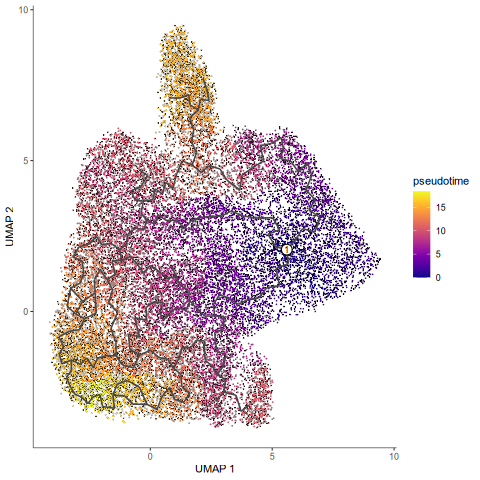

In [25]:
%%R
print(p)

#### **Fig. 6b** Graph visualization of NK substates and terminal clusters defined by pseudotemporal ordering with staVIA. 

**Environment Compatibility Note**

Running staVIA requires scipy==1.11.4, numpy==1.26.4, and dask==2026.3.0.

While cellphonedbV5 requies scipy>=1.12.0, which is not compatible with staVIA. 

Our default scipy version is 1.16.0. Therefore, **trajectory analysis using staVIA must be performed in an independent environment with the specified dependency versions**, and results are saved and loaded into the main analysis environment for visualization and downstream plotting.

This approach ensures full reproducibility while complying with the strict version constraints of each tool.

In [12]:
import pyVIA.core as via
#set parameters for Via 2.0
memory=100 #this is a high memory value and will result in probabilistic pathways that avoid transitioning into unrelated cell populations 
cluster_graph_pruning = 0.15 #level of pruning done on the cluster graph. higher number means less pruning (values can range from 0-3 standard deviations)
edgepruning_clustering_resolution = 0.15  # regulates number of clusters. Higher values means fewer clusters (values can range from 0-3 standard deviations)
random_seed = 1234 
knn = 30  # number of neighbors in the knn graph
knn_sequential = 15  # number of neighbors additionally created between sequentially adjacent time points 
n_pcs = 10 # number of principal components
velo_weight = 0  # 0.7 #weight given to velocity based direction compared to pseudotime based direction
t_diff_step = 1 #edges extending between nodes that are more than 2 time steps apart will be removed (i.e. equal to 3 or more time steps apart)
root = ['C01_NK_MKI67'] #for reproducibility, we set the root here. the group level root assignment must correspond to a label that exists in the True-label parameter (must be passed inside a list). For autodetection based on rna-velocity it can be left as None. A single cell index can also be passed e.g. [256], means the 256th cell will be used as a root. Since we will be using the velocity matrices (see below), Via 2.0 will suggest a list of likely root cell states that the user can decide to choose between. It is helpful to examine the top 5 suggested roots and choose the one that seems most reasonable. Note in the output that Via 2.0's suggestions are almost all in the epibliast or Primitive streak state 
neighboring_terminal_states_threshold = 4
max_visual_outgoing_edges = 10#5 #used in differentiation flow chart plots
time_series = True
parc_numeric_cluster_labels = [i for i in adata_NK.obs['leiden-NK1']]
cluster_celltype_label = [i for i in adata_NK.obs['anno-NK']]
use_velocity = False
velo_weight = 0.5

if use_velocity:
    gene_matrix =np.asmatrix(adata_NK.layers['Ms'])
    velocity_matrix = np.asmatrix(adata_NK.layers['velocity'])
    velo_weight=velo_weight
else: 
    gene_matrix =None
    velocity_matrix = None
    velo_weight=0
vNK = via.VIA(adata_NK.obsm['X_pca_harmony'][:, 0:n_pcs], true_label = cluster_celltype_label,
        edgepruning_clustering_resolution=edgepruning_clustering_resolution,
        edgepruning_clustering_resolution_local=1, knn=knn, memory=memory,
        root_user=root, random_seed=random_seed,
        knn_sequential_reverse=knn_sequential,
        gene_matrix=gene_matrix, velocity_matrix=velocity_matrix,
        velo_weight=velo_weight,
        )

In [13]:
from datetime import datetime
print(f'{datetime.now()}\tRun Via2.0')
vNK.run_VIA()
print(f'{datetime.now()}\tEnd Via2.0 computation')

2026-04-10 18:01:08.131074	Run Via2.0
2026-04-10 18:01:08.131272	Running VIA over input data of 23666 (samples) x 10 (features)
2026-04-10 18:01:08.131314	Knngraph has 30 neighbors
2026-04-10 18:01:13.970329	Finished global pruning of 30-knn graph used for clustering at level of 0.15. Kept 48.8 % of edges. 
2026-04-10 18:01:14.086167	Number of connected components used for clustergraph  is 1
2026-04-10 18:01:15.182418	Commencing community detection
2026-04-10 18:01:18.361774	Finished community detection. Found 88 clusters.
2026-04-10 18:01:18.369433	Merging 66 very small clusters (<10)
2026-04-10 18:01:18.373765	Finished detecting communities. Found 22 communities
2026-04-10 18:01:18.375116	Making cluster graph. Global cluster graph pruning level: 0.15
2026-04-10 18:01:18.438120	Graph has 1 connected components before pruning
2026-04-10 18:01:18.440099	Graph has 1 connected components after pruning
2026-04-10 18:01:18.440256	Graph has 1 connected components after reconnecting
2026-04-1

/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/core.py:176: UserWarning: WARNING: Implicitly set node IDs to the canonical node ordering due to missing IDs field in the raw CSR npz file. This warning message can be suppressed by setting implicit_ids to True in the read_npz function call, or by setting the --implicit_ids flag in the CLI
  g.set_node_ids(node_ids=None,


  0%|          | 0/1300 [00:00<?, ?it/s]

memory for rw2 hittings times  2. Using rw2 based pt
2026-04-10 18:01:24.363680	Identifying terminal clusters corresponding to unique lineages...
2026-04-10 18:01:24.363713	Closeness:[0, 2, 4, 5, 6, 7, 9, 10, 16, 18, 19]
2026-04-10 18:01:24.363725	Betweenness:[0, 2, 3, 4, 5, 6, 7, 8, 9, 15, 16, 17, 18, 19]
2026-04-10 18:01:24.363733	Out Degree:[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 16, 18, 19]
2026-04-10 18:01:24.363917	Cluster 2 had 3 or more neighboring terminal states [3, 4, 9, 16] and so we removed cluster 4
2026-04-10 18:01:24.363945	Cluster 3 had 3 or more neighboring terminal states [2, 6, 10, 16] and so we removed cluster 6
2026-04-10 18:01:24.364001	Cluster 16 had 3 or more neighboring terminal states [2, 3, 10] and so we removed cluster 3
2026-04-10 18:01:24.364135	Terminal clusters corresponding to unique lineages in this component are [0, 2, 9, 10, 16, 18, 19] 
2026-04-10 18:01:24.364150	Calculating lineage probability at memory 100


/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/core.py:176: UserWarning: WARNING: Implicitly set node IDs to the canonical node ordering due to missing IDs field in the raw CSR npz file. This warning message can be suppressed by setting implicit_ids to True in the read_npz function call, or by setting the --implicit_ids flag in the CLI
  g.set_node_ids(node_ids=None,


  0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-10 18:01:28.986563	Cluster or terminal cell fate 0 is reached 85.0 times
2026-04-10 18:01:29.018507	Cluster or terminal cell fate 2 is reached 714.0 times
2026-04-10 18:01:29.051346	Cluster or terminal cell fate 9 is reached 661.0 times
2026-04-10 18:01:29.083488	Cluster or terminal cell fate 10 is reached 480.0 times
2026-04-10 18:01:29.111970	Cluster or terminal cell fate 16 is reached 665.0 times
2026-04-10 18:01:29.146331	Cluster or terminal cell fate 18 is reached 85.0 times
2026-04-10 18:01:29.182386	Cluster or terminal cell fate 19 is reached 23.0 times
2026-04-10 18:01:29.213330	There are (7) terminal clusters corresponding to unique lineages {0: 'C08_Malig_H2AC11', 2: 'C05_NKT_FGFBP2', 9: 'C06_NK_KIT', 10: 'C02_NK_CD56', 16: 'C02_NK_CD56', 18: 'C08_Malig_H2AC11', 19: 'C07_Malig_IL2RA'}
2026-04-10 18:01:29.213364	Begin projection of pseudotime and lineage likelihood
2026-04-10 18:01:29.798953	Cluster graph layout based on forward biasing
2026-04-10 18:01:29.800442	Start

/home/rzh/miniconda3/lib/python3.11/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


The trajectory reconstruction using staVIA yielded consistent topological structures compared to the original study. While minor variations in the visual layout (e.g., rotation or node positioning) were observed due to the stochastic nature of the graph-layout algorithms and software version updates, the identification of terminal clusters and the overall lineage hierarchy remained robust and identical to the reported findings.

2026-04-10 18:01:58.927276	Plot Via2.0 cluster graph


/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:3696: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  group_frac[ii][group_i] = true_label_in_group_i.count(ii)
/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plo

tune edges False


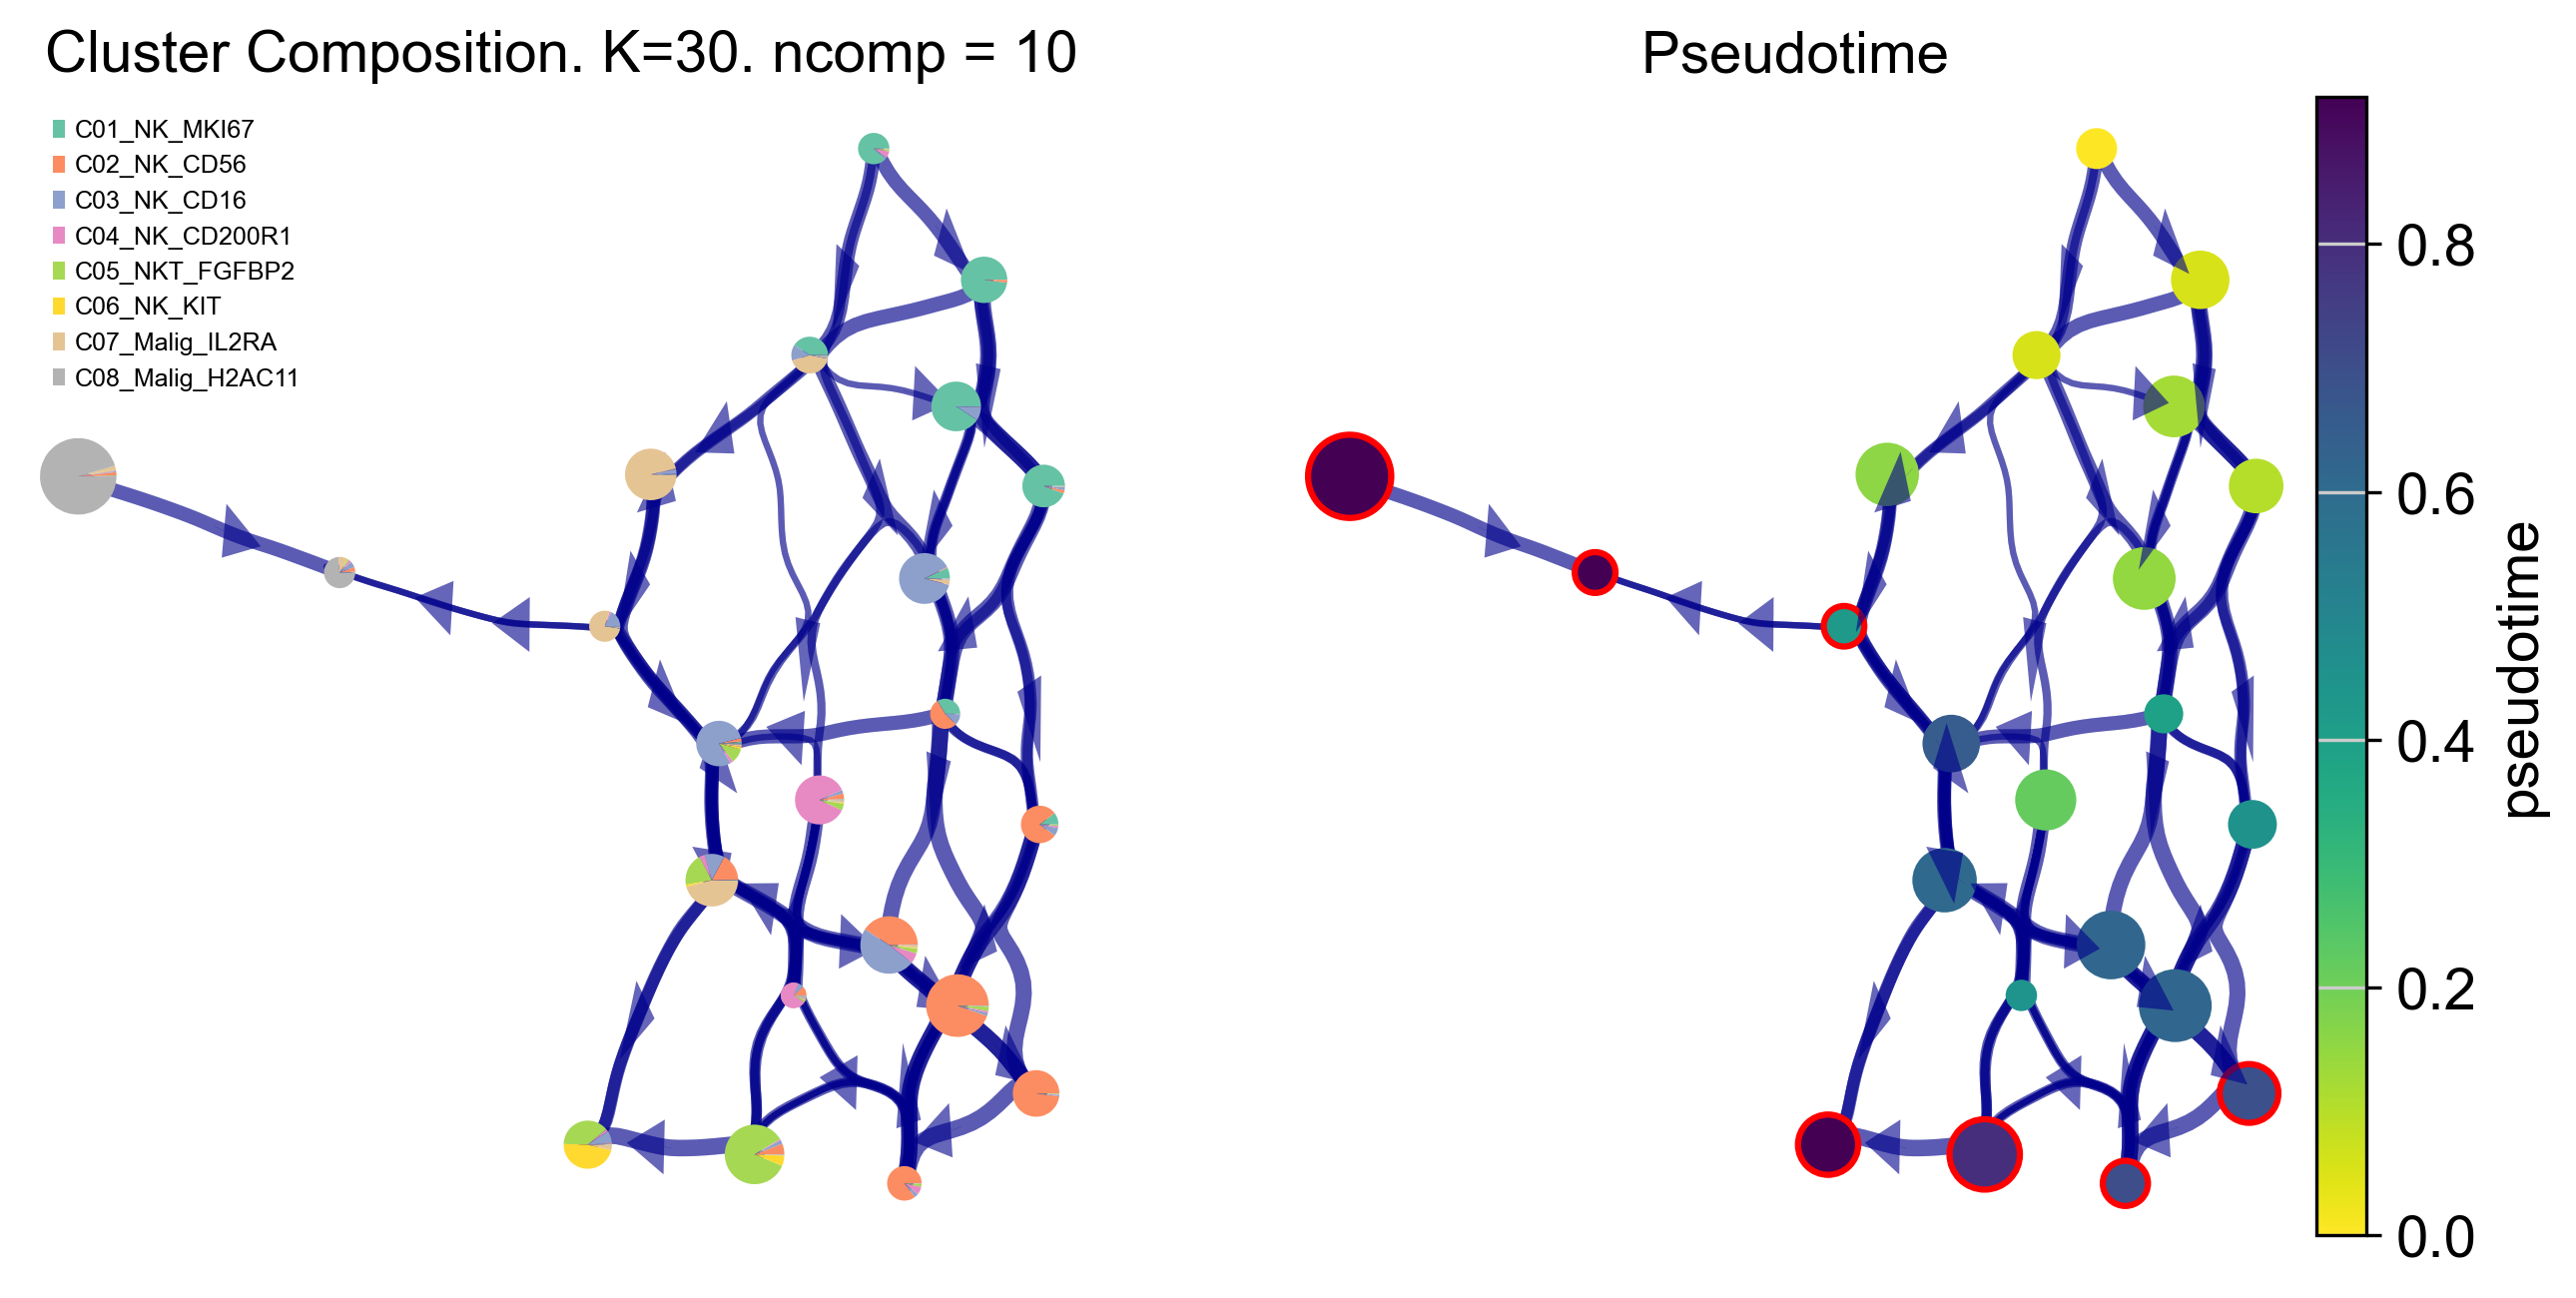

In [14]:
print(f'{datetime.now()}\tPlot Via2.0 cluster graph')

f, ax, ax1=via.plot_piechart_viagraph(via_object=vNK, headwidth_arrow=0.2, show_legend=True, ax_text=False, pie_size_scale=0.6, cmap_piechart='Set2', 
                        highlight_terminal_clusters=True, size_node_notpiechart=0.8)
f.set_size_inches(10, 5)
f.savefig(f'{figPath}/Fig6b.pdf', bbox_inches='tight')

#### **Fig. 6c** Changes in lineage proportions over pseudotime. 
The upper panel depicts the dynamic changes in the proportions of different NK cell lineages. The lower panel depicts the changes in the proportions of NK cells in pre-ICI, post-ICI, and PBMC samples.

head df full          pt         celltype
0  0.443542   C04_NK_CD200R1
1  0.582065      C03_NK_CD16
2  0.611608      C02_NK_CD56
3  0.848898   C05_NKT_FGFBP2
4  0.423594  C07_Malig_IL2RA
dict temp Counter({'C01_NK_MKI67': 0.9066427289048474, 'C04_NK_CD200R1': 0.05206463195691203, 'C07_Malig_IL2RA': 0.017953321364452424, 'C03_NK_CD16': 0.012567324955116697, 'C05_NKT_FGFBP2': 0.00718132854578097, 'C08_Malig_H2AC11': 0.0017953321364452424, 'C06_NK_KIT': 0.0017953321364452424})
dict temp Counter({'C01_NK_MKI67': 0.7789994502473887, 'C07_Malig_IL2RA': 0.1462341946124244, 'C03_NK_CD16': 0.05332600329851567, 'C02_NK_CD56': 0.009895547003848268, 'C08_Malig_H2AC11': 0.009345794392523364, 'C04_NK_CD200R1': 0.0021990104452996153})
dict temp Counter({'C01_NK_MKI67': 0.6147239263803681, 'C03_NK_CD16': 0.3512269938650307, 'C07_Malig_IL2RA': 0.020552147239263803, 'C04_NK_CD200R1': 0.005214723926380368, 'C02_NK_CD56': 0.003987730061349694, 'C08_Malig_H2AC11': 0.0036809815950920245, 'C06_NK_KIT': 0.000

/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:863: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9066427289048474' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_population.loc[minpt + (index_i + 1) * interval_step, key_pop_i] = dict_temp[key_pop_i]
/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:863: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.012567324955116697' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_population.loc[minpt + (index_i + 1) * interval_step, key_pop_i] = dict_temp[key_pop_i]
/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:863: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future versio

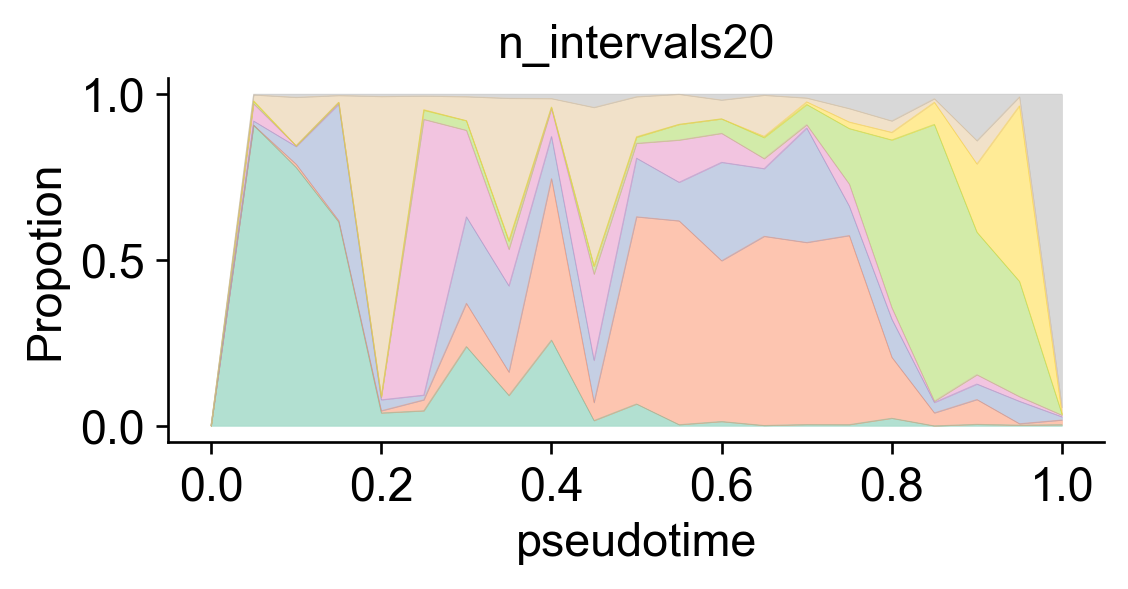

In [15]:
ax = via.plot_population_composition(vNK, xlabel='pseudotime', ylabel='Propotion', legend=False,  title='', cmap='Set2', n_intervals=20)
ax.figure.set_size_inches(5, 2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.figure.savefig(f'{figPath}/Fig6c-upper.pdf', bbox_inches='tight')

head df full          pt celltype
0  0.443542      Pre
1  0.582065      Pre
2  0.611608      Pre
3  0.848898      Pre
4  0.423594      Pre
dict temp Counter({'Pre': 0.9946140035906643, 'Post': 0.005385996409335727})
dict temp Counter({'Pre': 0.9983507421660253, 'Post': 0.0016492578339747114})
dict temp Counter({'Pre': 0.9947852760736197, 'Post': 0.0049079754601227, 'PBMC': 0.00030674846625766873})
dict temp Counter({'Pre': 0.9933829611248967, 'Post': 0.004962779156327543, 'PBMC': 0.0016542597187758478})
dict temp Counter({'Pre': 0.9946524064171123, 'Post': 0.004456327985739751, 'PBMC': 0.00089126559714795})
dict temp Counter({'Pre': 1.0})
dict temp Counter({'Pre': 0.9938837920489296, 'Post': 0.0061162079510703364})
dict temp Counter({'Pre': 0.9913793103448276, 'Post': 0.00646551724137931, 'PBMC': 0.0021551724137931034})
dict temp Counter({'Pre': 0.9880636604774535, 'Post': 0.009283819628647215, 'PBMC': 0.002652519893899204})
dict temp Counter({'Pre': 0.9850905218317358, 'Post': 0.01384

/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:863: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.005385996409335727' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_population.loc[minpt + (index_i + 1) * interval_step, key_pop_i] = dict_temp[key_pop_i]
/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:863: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9946140035906643' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_population.loc[minpt + (index_i + 1) * interval_step, key_pop_i] = dict_temp[key_pop_i]
/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:863: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future versio

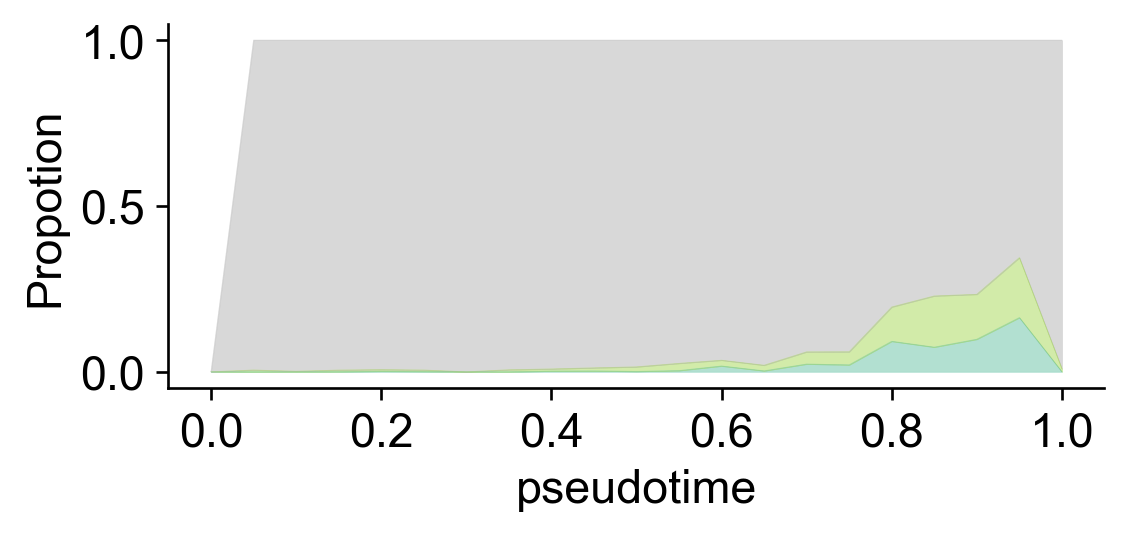

In [16]:
ax = via.plot_population_composition(vNK, celltype_list=list(adata_NK.obs['treatment']),xlabel='pseudotime', ylabel='Propotion', legend=False,  title='', cmap='Set2', n_intervals=20)
ax.figure.set_size_inches(5, 2)
ax.set_title('')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.figure.savefig(f'{figPath}/Fig6c-lower.pdf')

#### **Fig. 6d** Three-dimensional diffusion map visualization of the NK cell gene trajectory, including annotations for selected genes.

In [17]:
# ---------------------------------------------------------
# GeneTrajectory Analysis Workflow
# ---------------------------------------------------------
# This section defines the pipeline for inferring gene trajectories
# using the GeneTrajectory method. Unlike traditional cell trajectory
# inference, this approach analyzes the dynamics of gene expression
# distributions across a cell graph using optimal transport metrics.
# It identifies sequential gene programs and their pseudo-temporal
# ordering without relying on predefined cell lineages.
# ---------------------------------------------------------

from datetime import datetime
from gene_trajectory.add_gene_bin_score import add_gene_bin_score
from gene_trajectory.coarse_grain import select_top_genes, coarse_grain_adata
from gene_trajectory.extract_gene_trajectory import get_gene_embedding, extract_gene_trajectory
from gene_trajectory.get_graph_distance import get_graph_distance
from gene_trajectory.gene_distance_shared import cal_ot_mat
from gene_trajectory.run_dm import run_dm
from gene_trajectory.plot.gene_trajectory_plots import plot_gene_trajectory_3d, plot_gene_trajectory_umap, plot_gene_trajectory_2d
from gene_trajectory.util.download_file import download_file_if_missing

def timeprint(string):
  print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {string}")

def run_gene_trajectory(adata, add_genes=[]):
  timeprint("Start running gene trajectory...")
  genes = select_top_genes(adata, layer='Raw', n_variable_genes=500)
  timeprint(f"Found {len(genes)} highly variable genes.")
  genes = list(genes)
  genes.extend(add_genes)
  genes = np.unique(genes)
  run_dm(adata)
  timeprint("Running Cell graph...")
  cell_graph_dist = get_graph_distance(adata, k=10)
  gene_expression_updated, graph_dist_updated = coarse_grain_adata(adata, graph_dist=cell_graph_dist, features=genes, n=500)
  timeprint("Evaluating gene distance...")
  gene_dist_mat = cal_ot_mat(gene_expr=gene_expression_updated, 
                           ot_cost=graph_dist_updated, 
                           show_progress_bar=True)
  timeprint("Generating gene distance...")
  gene_embedding, _ = get_gene_embedding(gene_dist_mat, k = 5)
  timeprint("Generating gene_trajectory...")
  gene_trajectory = extract_gene_trajectory(gene_embedding, gene_dist_mat, t_list = [4, 8, 7], gene_names=genes, k=5)
  return gene_trajectory

def refine_gene_trajectory(adata, genes):
  timeprint("Running Cell graph...")
  cell_graph_dist = get_graph_distance(adata, k=10)
  gene_expression_updated, graph_dist_updated = coarse_grain_adata(adata, graph_dist=cell_graph_dist, features=genes, n=500)
  timeprint("Evaluating gene distance...")
  gene_dist_mat = cal_ot_mat(gene_expr=gene_expression_updated, 
                           ot_cost=graph_dist_updated, 
                           show_progress_bar=True)
  timeprint("Generating gene distance...")
  gene_embedding, _ = get_gene_embedding(gene_dist_mat, k = 5)
  timeprint("Generating gene_trajectory...")
  gene_trajectory = extract_gene_trajectory(gene_embedding, gene_dist_mat, t_list = [4, 8, 7], gene_names=genes, k=5)
  return gene_trajectory

/home/rzh/miniconda3/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [ ]:
gene_trajectory_NK = run_gene_trajectory(adata_NK)

[2026-04-10 18:06:46] Start running gene trajectory...
[2026-04-10 18:06:48] Found 285 highly variable genes.


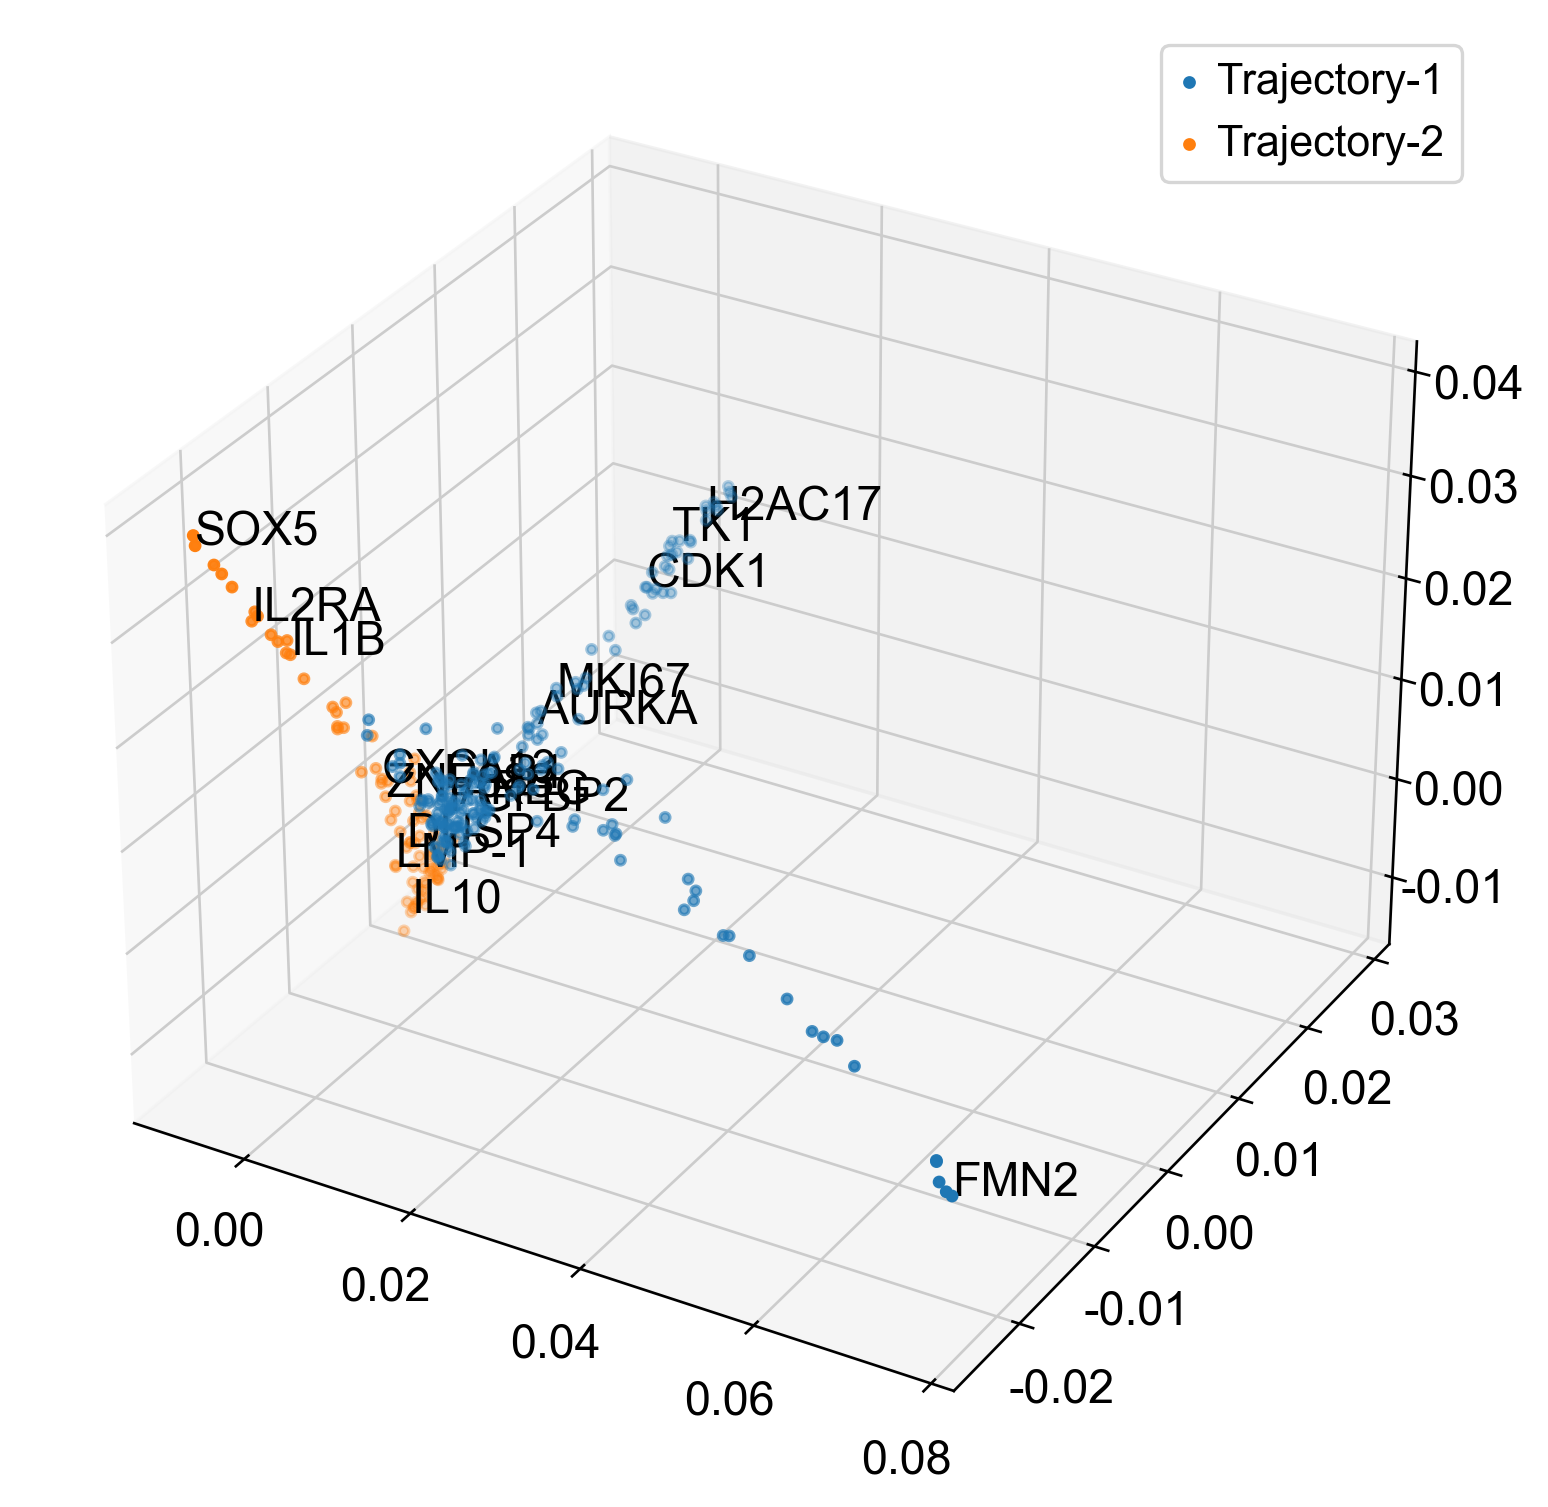

In [19]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
label_genes=['FMN2', 'IL2RA', 'LMP-1', 'MKI67', 'CXCL13'
             , 'SOX5', 'H2AC17', 'CDK1',  'IL10', 'DUSP4', 'ZNF683', 'IL1B',
             'AREG', 'FGFBP2', 'AURKA', 'TK1', 'DAB1']
gene_trajectory = gene_trajectory_NK
s=8
selections = pd.Categorical(gene_trajectory.selected)

for c in 'DM_1', 'DM_2', 'DM_3', 'selected':
    if c not in gene_trajectory.columns:
        raise ValueError(f'Column {c} is not present in gene trajectory DataFrame')
for c in selections.categories:
    idxs = selections == c
    ax.scatter(xs=gene_trajectory['DM_1'][idxs],
                ys=gene_trajectory['DM_2'][idxs],
                zs=gene_trajectory['DM_3'][idxs],
                s=s,
                label=c)

if label_genes:
    for g in label_genes:
        ax.text(x=gene_trajectory['DM_1'][g],
                y=gene_trajectory['DM_2'][g],
                z=gene_trajectory['DM_3'][g],
                s=g)
ax.legend()
fig.savefig(f"{figPath}/Fig6d.pdf", bbox_inches='tight')

#### **Fig. 6e** Three-dimensional diffusion map visualization of the T cell gene trajectory, including annotations for selected genes.

In [881]:
adata_subT = adata_T[~adata_T.obs['anno-subTfixed'].isin(['C14_NK/NKT_NCAM1', 'C15_mixed'])]
adata_subT = adata_subT[adata_subT.obs['batch'].isin(['NK11_0', 'NK11_1','NK5_0', 'NK5_1', 'NK6_0', 'NK6_1', 'NK7_0', 'NK7_1', 'NK8_0', 'NK8_1'])]
adata_subT

View of AnnData object with n_obs × n_vars = 34800 × 33727
    obs: 'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'leiden-1', 'leiden-pca', 'anno-pca', 'treatment', 'leiden-T', 'annotation', 'cnv_status', 'cnv_score', 'exhaustion', 'cytotoxicity', 'anno-T', 'clonal_size', 'spot_size', 'CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative', 'preKNN_CytoTRACE2_Score', 'preKNN_CytoTRACE2_Potency', 'anno-subT', 'anno-Tfixed', 'anno-subTfixed', 'proliferation', 'anno-subT1', 'anno-focus', 'CellStateLabels', 'anno-NK', 'inflammation', 'stress'
    var: 'ID', 'name', 'type', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'airr:chain_pairing_colors', 'airr:clonal_expansion_colors', 'airr:clone_id_colors', 'airr:receptor_subtype_colors', 'airr:receptor

In [882]:
gene_trajectory_T = run_gene_trajectory(adata_subT, add_genes=['HLA-DQA1', 'SELL','CCR7','PDCD1', 'GZMK', 'ENTPD1', 'TIGIT', 'HAVCR2', 'CD200','TCF7', 'IL7R', 'ZNF683', 'LAG3', 'CTLA4', 'MSI2', 'XIST', 'CXCL13', 'DAB1', 'KSR1', 'TTN', 'TK1', 'CD38'])

[2026-04-10 15:06:03] Start running gene trajectory...


/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/preprocessing/_qc.py:145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



[2026-04-10 15:06:06] Found 365 highly variable genes.
[2026-04-10 15:28:54] Running Cell graph...
[2026-04-10 15:32:51] Evaluating gene distance...


100%|████████████████████████████████| 72390/72390 [00:00<00:00, 111351.98it/s]


[2026-04-10 15:34:43] Generating gene distance...
[2026-04-10 15:34:43] Generating gene_trajectory...


WARNING	root:extract_gene_trajectory.py:extract_gene_trajectory()- Early stop reached. 0 gene trajectories were retrieved.


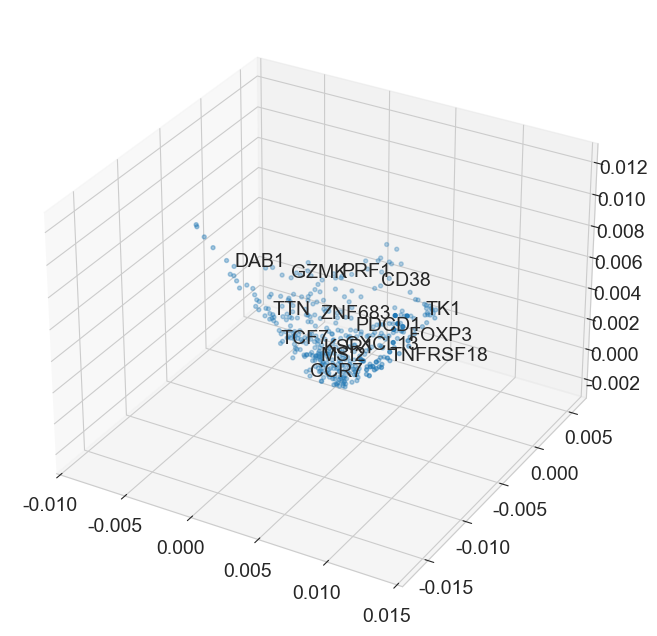

In [883]:
fig = plt.figure(figsize=(8, 8)) 
ax = fig.add_subplot(111, projection='3d')
label_genes=['TTN','DAB1','ZNF683','PRF1','KSR1','GZMK','TNFRSF18','CD38','PDCD1','CCR7', 'MSI2',  'CXCL13','TCF7','TK1','FOXP3']
gene_trajectory = gene_trajectory_T
s=8
selections = pd.Categorical(gene_trajectory.selected)

for c in 'DM_1', 'DM_2', 'DM_3', 'selected':
    if c not in gene_trajectory.columns:
        raise ValueError(f'Column {c} is not present in gene trajectory DataFrame')
for c in selections.categories:
    idxs = selections == c
    ax.scatter(xs=gene_trajectory['DM_1'][idxs],
                ys=gene_trajectory['DM_2'][idxs],
                zs=gene_trajectory['DM_3'][idxs],
                s=s,
                label=c)

if label_genes:
    for g in label_genes:
        ax.text(x=gene_trajectory['DM_1'][g],
                y=gene_trajectory['DM_2'][g],
                z=gene_trajectory['DM_3'][g],
                s=g)
fig.savefig(f"{figPath}/Fig6e.pdf", bbox_inches='tight')

#### **Fig. 6f** Bubble heatmaps illustrate the cell-cell communication of immune checkpoint-associated ligand-receptor pairs between exhausted T cells and malignant NK/T cells, before and after ICI treatment. 
Dot color represents the scaled mean interaction strength, and dot size indicates the statistical significance (-log₁₀P value) derived from permutation testing, with red dots marking significant interactions (P < 0.05).

In [27]:
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method
import ktplotspy as kpy

In [ ]:
# Concatenate NK and purified T cell subsets (exclude NK/NKT-like and mixed states) to form combined T-NK dataset
adata_CC = adata_NK.concatenate(adata_T[~adata_T.obs['CellStateLabels'].isin(['T14: NK/NKT-like',
       'T15: mixed'])], batch_key='major', batch_categories=['NK', 'T'])

In [30]:
# ----------------------
# CellPhoneDB analysis for Pre-treatment samples
# Subset adata to Pre-treatment group, export h5ad and meta file for CellPhoneDB v5
# Run CellPhoneDB statistical analysis to infer cell-cell communication between cell states
# ----------------------
groupby = 'CellStateLabels'  # adata.obs['annotation'] for sc data
adata_in = adata_CC[adata_CC.obs['treatment'].isin(['Pre'])].copy()
adata_in.write_h5ad("./data/adata-NKTCL-CC-Pre.h5ad")
meta = pd.DataFrame(adata_in.obs[groupby].copy())
meta = meta.reset_index()
meta.columns=['Cell', 'cell_type']
meta.to_csv("./data/meta.txt", sep='\t', index=False)

cpdb_res_pre = cpdb_statistical_analysis_method.call(
cpdb_file_path="./data/cellphonedb.zip",
meta_file_path="./data/meta.txt",
counts_file_path=f"./data/adata-NKTCL-CC-Pre.h5ad",
counts_data='hgnc_symbol',
output_path="./data",
threads=16,
)

Reading user files...
The following user files were loaded successfully:
./data/adata-NKTCL-CC-Pre.h5ad
./data/meta.txt
[ ][CORE][11/04/26-08:20:51][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:16 Precision:3
[ ][CORE][11/04/26-08:21:00][INFO] Running Real Analysis
[ ][CORE][11/04/26-08:21:00][INFO] Running Statistical Analysis


100%|██████████████████████████████████████| 1000/1000 [12:53<00:00,  1.29it/s]


[ ][CORE][11/04/26-08:33:57][INFO] Building Pvalues result
[ ][CORE][11/04/26-08:33:58][INFO] Building results
Saved deconvoluted to ./data/statistical_analysis_deconvoluted_04_11_2026_083358.txt
Saved deconvoluted_percents to ./data/statistical_analysis_deconvoluted_percents_04_11_2026_083358.txt
Saved means to ./data/statistical_analysis_means_04_11_2026_083358.txt
Saved pvalues to ./data/statistical_analysis_pvalues_04_11_2026_083358.txt
Saved significant_means to ./data/statistical_analysis_significant_means_04_11_2026_083358.txt


In [45]:
# ----------------------
# CellPhoneDB analysis for Post-treatment samples
# Subset adata to Post-treatment group, export h5ad and meta file for CellPhoneDB v5
# Run CellPhoneDB statistical analysis to infer cell-cell communication between cell states
# ----------------------
groupby = 'CellStateLabels'  # adata.obs['annotation'] for sc data
adata_in = adata_CC[adata_CC.obs['treatment'].isin(['Post', 'PBMC'])].copy() # use highly variable genes
adata_in.write_h5ad("./data/adata-NKTCL-CC-Post.h5ad")
meta = pd.DataFrame(adata_in.obs[groupby].copy())
meta = meta.reset_index()
meta.columns=['Cell', 'cell_type']
meta.to_csv("./data/meta.txt", sep='\t', index=False)

cpdb_res_post = cpdb_statistical_analysis_method.call(
cpdb_file_path="./data/cellphonedb.zip",
meta_file_path="./data/meta.txt",
counts_file_path=f"./data/adata-NKTCL-CC-Post.h5ad",
counts_data='hgnc_symbol',
output_path="./data",
threads=16,
)

Reading user files...
The following user files were loaded successfully:
./data/adata-NKTCL-CC-Post.h5ad
./data/meta.txt
[ ][CORE][11/04/26-09:22:36][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:16 Precision:3
[ ][CORE][11/04/26-09:22:37][INFO] Running Real Analysis
[ ][CORE][11/04/26-09:22:37][INFO] Running Statistical Analysis


100%|██████████████████████████████████████| 1000/1000 [04:06<00:00,  4.06it/s]


[ ][CORE][11/04/26-09:26:47][INFO] Building Pvalues result
[ ][CORE][11/04/26-09:26:48][INFO] Building results
Saved deconvoluted to ./data/statistical_analysis_deconvoluted_04_11_2026_092648.txt
Saved deconvoluted_percents to ./data/statistical_analysis_deconvoluted_percents_04_11_2026_092648.txt
Saved means to ./data/statistical_analysis_means_04_11_2026_092648.txt
Saved pvalues to ./data/statistical_analysis_pvalues_04_11_2026_092648.txt
Saved significant_means to ./data/statistical_analysis_significant_means_04_11_2026_092648.txt


In [39]:
from plotnine import (
    aes,
    element_blank,
    element_rect,
    element_text,
    geom_point,
    ggplot,
    ggtitle,
    guide_colourbar,
    guide_legend,
    guides,
    options,
    scale_alpha_continuous,
    scale_colour_continuous,
    scale_colour_manual,
    scale_fill_continuous,
    scale_fill_manual,
    scale_size_continuous,
    theme,
    theme_bw,
    theme_matplotlib
)

def myplot_cpdb(df, figure_size = (5,6)):
    options.figure_size = figure_size
    colm = "scaled_means"
    highlight_size = 0.75
    max_size = 4
    max_highlight_size = 1
    stroke = "x_stroke"
    default_style = True
    highlight_col = "#d62728"
    cmap_name = "viridis"
    DEFAULT_SEP = ">@<"
    # set global figure size

    g = ggplot(
        df,
        aes(
            x="celltype_group",
            y="interaction_group",
            colour="significant",
            fill=colm,
            size='neglog10p',
            stroke=stroke,
        ),
    )
    g = (
        g
        + geom_point(
            na_rm=True,
        )
        + theme_bw()
        # + theme_matplotlib(rc={"figure.figsize": (4,6), 'font.family': 'Arial'})
        + theme(
            axis_text_x=element_text(angle=90, hjust=0, colour="#000000"),
            axis_text_y=element_text(colour="#000000"),
            axis_ticks=element_blank(),
            axis_title_x=element_blank(),
            axis_title_y=element_blank(),
            legend_key=element_rect(alpha=0, width=0, height=0),
            legend_direction="vertical",
            legend_box="vertical",
        )
        + scale_size_continuous(range=(0, max_size), aesthetics=["size"])
        + scale_size_continuous(range=(0, max_highlight_size), aesthetics=["stroke"])
    )
    if default_style:
        g = (
            g
            + scale_colour_manual(values=highlight_col, na_translate=False)
            + guides(
                fill=guide_colourbar(),
                size=guide_legend(
                    reverse=True,
                    order=2,
                ),
                stroke=guide_legend(
                    reverse=True,
                    order=3,
                ),
            )
            + scale_fill_continuous(cmap_name=cmap_name)
        )
    if highlight_size is not None:
        g = g + guides(stroke=None)
    return g

In [42]:
df = kpy.plot_cpdb(
        adata=adata_CC[adata_CC.obs['treatment'].isin(['Pre'])],
        cell_type1= 'T05: pTex_CD39|T06: Tex_CD8|T07: Tex_CD4',
        cell_type2='NK02: Malig_CD56|NK08: Malig_IL2RA|T12: Tprol_MKI67|T13: Malig_MSI2',
        means=cpdb_res_pre['means'],
        pvals=cpdb_res_pre['pvalues'],
        genes=["PDCD1", 'CTLA4', 'TIGIT', 'CD274', 'HLE', 'CXC', 'CCL', 'CD2', 'ENTPD1', 'CD86', 'IL10', 'DPP4'],
        max_size=4,
        max_highlight_size=1,
        highlight_size=0.75,
        degs_analysis=False,
        standard_scale=True,
        return_table=True,
        celltype_key=groupby,
        keep_significant_only=True, 
        figsize=(7,7),
        )

In [43]:
DEFAULT_SEP = ">@<"
df.interaction_group = [c.split(DEFAULT_SEP * 3)[1] for c in df.interaction_group]
y_order = ['IL10-IL10-receptor', 
           'CD274-PDCD1', 
           'CD274-CD80', 
           'NECTIN3-TIGIT',
           'ENTPD1-ADORA2A',
           'CD80-CTLA4',
           'CD86-CTLA4', 
           'CD200-CD200R1',
           'CD70-CD27',
         'CXCL2-DPP4',
         'CXCL9-DPP4',
           'CXCL10-DPP4',
           'CCL22-DPP4',
           'CCL3-CCR1', 
           'CCL3-CCR5',
           'CCL4-CCR5', 
           'CCL5-CCR1',
         'CCL5-CCR5', 
           'CD58-CD2', 
           'CD86-CD28',
             'CD80-CD28',
             'CD48-CD244',
             'CXCL10-CXCR3',
             'CXCL9-CXCR3',
             'CXCL13-CXCR5']
y_order.reverse()
df['interaction_group'] = pd.Categorical(df['interaction_group'], categories=y_order, ordered=True)

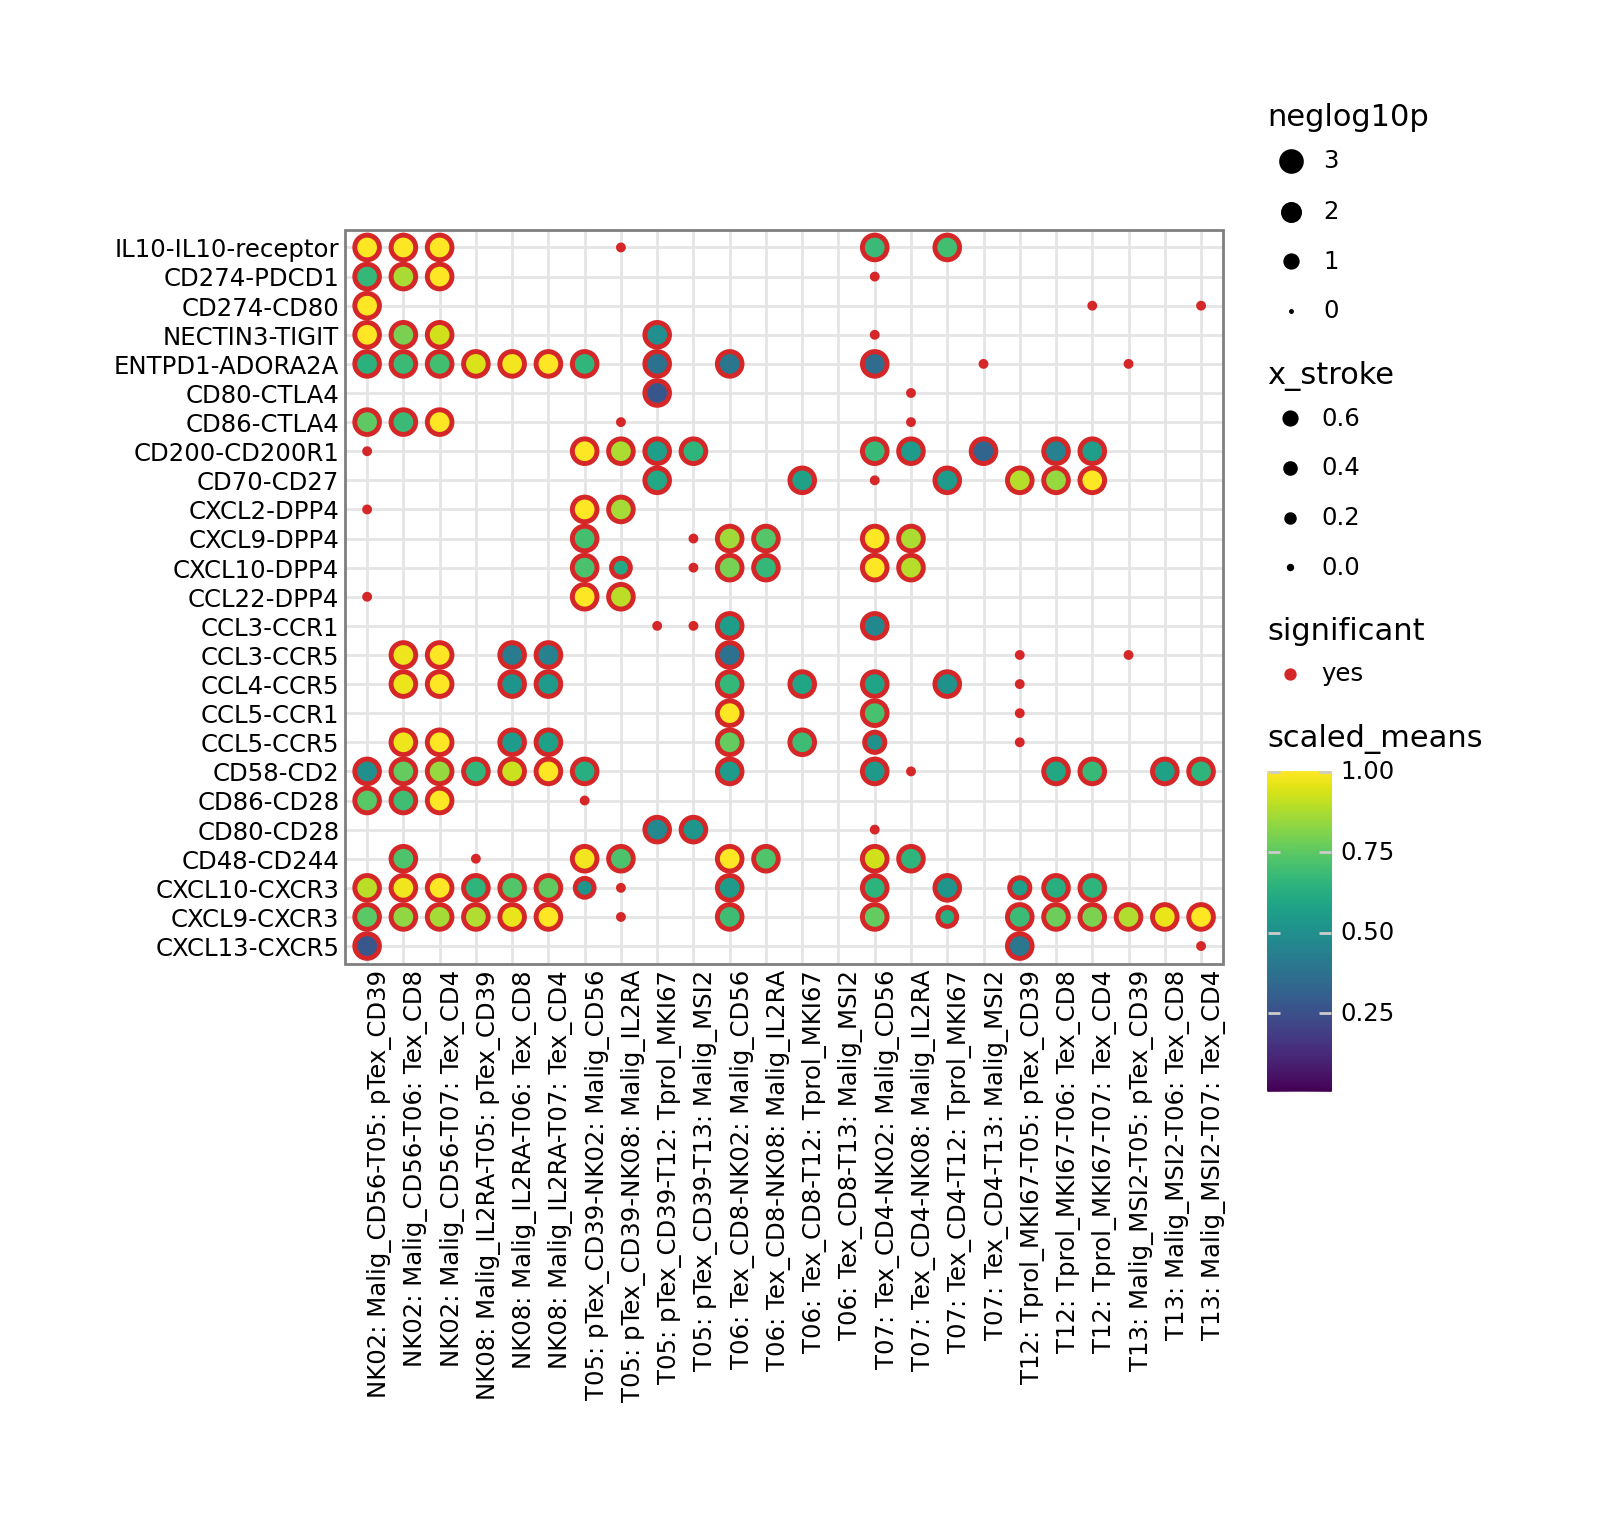

In [44]:
ax_Tex_pre = myplot_cpdb(df, figure_size=(7,6))
ax_Tex_pre.save(f"{figPath}/Fig6f-pre.pdf")
ax_Tex_pre.show()

In [46]:
df1 = kpy.plot_cpdb(
            adata=adata_CC[adata_CC.obs['treatment'].isin(['Post'])],
            cell_type1= 'T05: pTex_CD39|T06: Tex_CD8|T07: Tex_CD4',
            cell_type2='NK02: Malig_CD56|NK08: Malig_IL2RA|T12: Tprol_MKI67|T13: Malig_MSI2',
            means=cpdb_res_post['means'],
            pvals=cpdb_res_post['pvalues'],
            genes=["PDCD1", 'CTLA4', 'TIGIT', 'CD274', 'HLE', 'CXC', 'CCL', 'CD2', 'ENTPD1', 'CD86', 'IL10', 'DPP4'],
            max_size=4,
            max_highlight_size=1,
            highlight_size=0.75,
            degs_analysis=False,
            cluster_rows=True,
            standard_scale=True,
            celltype_key=groupby,
            keep_significant_only=True,
            figsize=(7,3.5),
            return_table=True
        )

In [47]:
DEFAULT_SEP = ">@<"

df1.interaction_group = [c.split(DEFAULT_SEP * 3)[1] for c in df1.interaction_group]
interaction_groups = np.unique(df.interaction_group)
y_order = ['IL10-IL10-receptor', 'CD274-PDCD1', 'CD274-CD80', 'NECTIN3-TIGIT','ENTPD1-ADORA2A','CD80-CTLA4',
           'CD86-CTLA4', 'CD200-CD200R1','CD70-CD27','CXCL2-DPP4','CXCL9-DPP4','CXCL10-DPP4',
           'CCL22-DPP4','CCL3-CCR1', 'CCL3-CCR5','CCL4-CCR5','CCL5-CCR4', 'CCL5-CCR1','CCL5-CCR5', 'CD58-CD2', 
           'CD86-CD28','CD80-CD28','CD48-CD244','CXCL10-CXCR3','CXCL9-CXCR3','CXCL13-CXCR5']
y_order.reverse()

df1['interaction_group'] = pd.Categorical(df1['interaction_group'], categories=y_order, ordered=True)

In [50]:
ax_Tex_post = myplot_cpdb(df1, figure_size=(7,4))
ax_Tex_post.save(f"{figPath}/Fig6f-post.pdf")